# 1. INTRODUCTION AND CONTEXT
The goal of this analysis is to investigate the disposable income around each Metro Station in Paris, to answer the following research questions:
-Whats the distirbution of average disposable income?
-Which Metro Line is the richest on average?
-Which Metro Line is the poorest on average?
-Which Metro Line ist the most unequal on average?

To answer this question, the following Data is used:
- Disposable Income Dataset of the French Gouverment: https://entrepot.recherche.data.gouv.fr/dataset.xhtml?persistentId=doi:10.57745/QRBINB ; The geotif raster was cropped and reprojected to a metric coordinate system using QGIS before 

- Shapefile of Stations, also provided by the french gouverment : https://www.data.gouv.fr/datasets/gares-et-stations-du-reseau-ferre-dile-de-france-par-ligne

- Shapefile of Metrolines, also provided by the french gouverment : https://www.data.gouv.fr/datasets/itineraires-de-metro-dans-openstreetmap


## METHODOLOGY
The methodology is to create a 300m buffer around the stations, using it as a simplyfied catchment area and calculate the spatial staitstic of average income. One has to note that also this approach is simplyfied, as it does not take into account the weight of each grid. So if a buffer touches 2 grids, it will be the unweighted average of both, no matter how much of which it touches. 

If a station is an interchange between several lines, it is treated as a different stations. This has one hand the reason, that some tracks between lines are quite far from each other, on the other hand there are actually some differences notable between the same staiton

## STRUCTURE OF OUTCOMES 
The project has the following structure :
1. Introduction and Context
2. Imports
3. Data Processing
4. Data Analysis
       
    -4.1 Income Distribution

    -4.2 Grouping Stations per Line 

    -4.3 Income per Line
    
    -4.4 Inequality per Line

5. Regression for Line X
6. Conclusion

The chapters follow in general the same structure with 3 parts:

- Markdown introducing the topic
- Code with prints of the major outcomes
- INTERPRETATION Markdown, summarizing the findings for the specific topic

# 2. IMPORTS
Import Tools, Functions and Data

In [1]:
#Pathfinder
import sys
import os
sys.path.append(os.path.abspath(".."))

#Packages
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

#Functions
from src.load_data import load_stations, load_income_grid
from src.raster_analysis import extract_mean_raster_value
from src.spatial import reproject_to_metric, create_buffers
from src.load_data import load_metro_lines
from rasterio.plot import show


In [2]:
#Import Income Raster
income_raster_path = "../data/raw/TIF/FRA_disp_inc_2015_EPSG_2154_crop.tif"

NOTE: According to my research, automatically donwload and adjust a tif is quite complicated, therefore. this would have been something i would ahve done if had more time/been more experienced

In [3]:
#Import Station Dataset
stations = load_stations(
    "https://data.iledefrance-mobilites.fr/api/explore/v2.1/catalog/datasets/emplacement-des-gares-idf/exports/geojson"
)
stations = reproject_to_metric(stations)
stations = stations[stations["mode"] == "METRO"]
stations.shape

(405, 28)

In [4]:
#Import Metro Lines
metro_lines_url = "https://magosm.magellium.com/geoserver/wfs?request=GetFeature&version=2.0.0&count=500000&outputFormat=application/json&typeName=magosm:subway_routes_line&srsName=EPSG:3857&bbox=-1538728.3025657746,4558105.012117158,2570526.338045301,6805965.139927621"
metro_lines = load_metro_lines(metro_lines_url)
metro_lines = reproject_to_metric(metro_lines)
metro_lines_paris = metro_lines[
    metro_lines["operator"] == "RATP"
].copy()

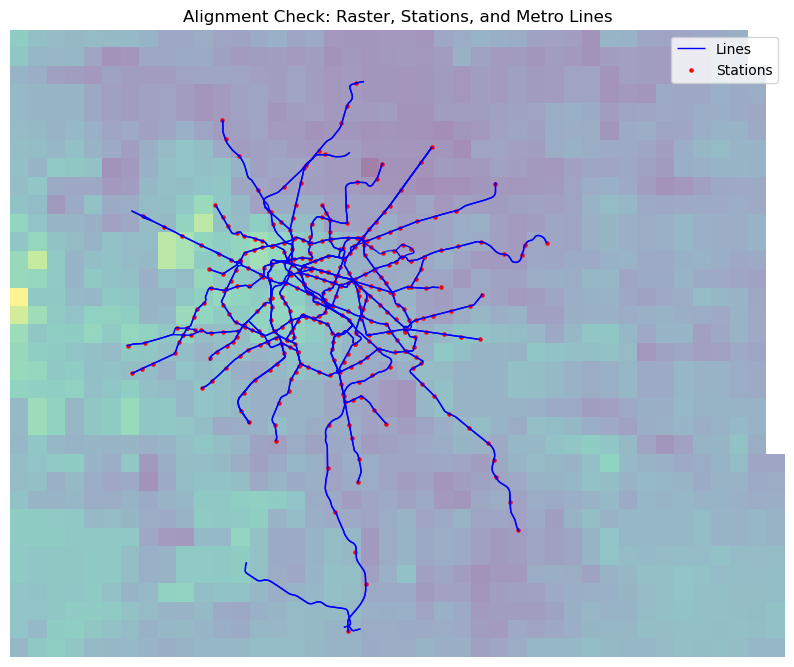

In [5]:
#Checkup Map to see if Raster, Stations and Lines are in the same System
fig, ax = plt.subplots(figsize=(10,10))
# Raster anzeigen
with rasterio.open(income_raster_path) as src:
    show(src, ax=ax, cmap="viridis", alpha=0.5)
metro_lines_paris.plot(ax=ax, color="blue", linewidth=1, label="Lines")
stations.plot(ax=ax, color="red", markersize=5, label="Stations")
ax.set_title("Alignment Check: Raster, Stations, and Metro Lines")
ax.set_axis_off()

plt.legend()
plt.show()

## 3. DATA PROCESSING
Steps: Create the Buffers, Do the raster analysis,create Maps to control
Outcome: 

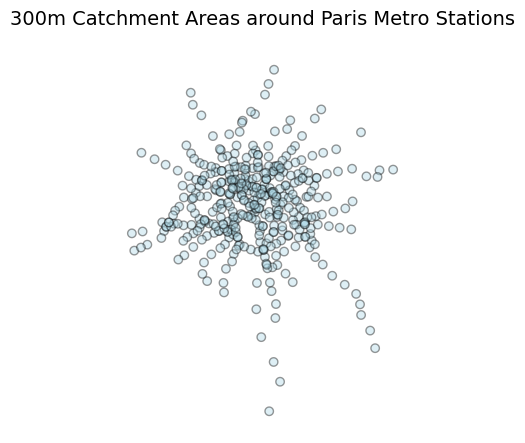

In [6]:
#CREATE THE BUFFERS:
station_buffers = create_buffers(stations, 300)

#CREATE A STATIC MAP
fig, ax = plt.subplots(figsize=(5, 5))

station_buffers.plot(
    ax=ax,
    alpha=0.4,
    edgecolor="black",
    color="lightblue"
)

ax.set_title("300m Catchment Areas around Paris Metro Stations", fontsize=14)
ax.set_axis_off()

plt.show()

#CREATE AN INTERACTIVE HTML MAP 
m = station_buffers.explore()
m.save("../outputs/1_MAP_Network.html")




In [7]:
#RASTERANALYSIS
station_buffers_income = extract_mean_raster_value(
    station_buffers,
    raster_path=income_raster_path,
    value_column="income_mean"
)

station_buffers_income["income_mean"].isna().sum()
station_buffers_income["income_mean"].describe()

count      405.000000
mean     32210.012566
std       5920.263834
min      18313.011719
25%      27469.699219
50%      32046.585938
75%      36723.921875
max      44404.005208
Name: income_mean, dtype: float64

PLAUSIBILITY CHECK

In [8]:
#10 richest Stations
top_stations = station_buffers_income.sort_values(
    by="income_mean",
    ascending=False
).head(10)

top_stations[["nom_gares", "indice_lig", "income_mean"]]

,nom_gares,indice_lig,income_mean
459,Monceau,2,44404.005208
721,Villiers,3,43928.445312
225,Villiers,2,43928.445312
119,Malesherbes,3,43893.585938
973,Courcelles,2,43458.015625
1080,Ternes,2,43458.015625
1101,Jasmin,9,42903.179688
126,Pont de Neuilly,1,42334.253906
1106,Michel Ange-Auteuil,10,42263.179688
870,Michel Ange-Auteuil,9,42263.179688


In [9]:
# 10 Poorest Stations
bottom_stations = station_buffers_income.sort_values(
    by="income_mean",
    ascending=True
).head(10)

bottom_stations[["nom_gares", "indice_lig", "income_mean"]]

,nom_gares,indice_lig,income_mean
710,Aimé Césaire,12,18313.011719
969,Mairie d'Aubervilliers,12,18417.355469
677,Front Populaire,12,19201.949219
1182,Fort d'Aubervilliers,7,19592.882812
1179,La Courneuve 8 Mai 1945,7,19598.752604
177,Aubervilliers Pantin - Quatre Chemins,7,19958.837240
856,Saint-Denis - Porte de Paris,13,20616.679688
857,Saint-Denis - Université,13,20719.195312
472,Basilique de Saint-Denis,13,20913.832031
102,Les Courtilles,13,21405.867188


INTERPRETATION: Since the richest stations are concentrated in the inner northwest of Paris and the poorest stations around the north-eastern banlieu, the result seems to be plausibel 

# 4. Analysis
The following chapter conducts the spatial analysis

## 4.1 Income Distribution
The first analysis will focus on the broad stats of the analysis, showing:

4.1.1  Distirbution Grid Cells per Station
4.1.2  Distribution Income Intervalls
4.1.3  Heatmap showing the Intervalls

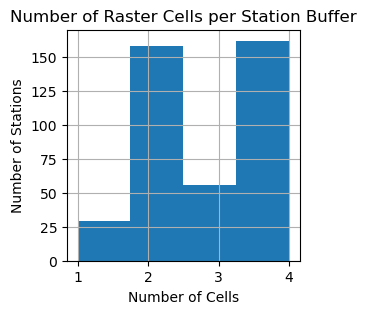

The minimum grid cells per station are: 1
The maximum grid cells per station are: 4


In [10]:
#4.1.1 Distribution Grid Cells per Station
plt.figure(figsize=(3,3))
station_buffers_income["n_cells"].hist(bins=4)
plt.title("Number of Raster Cells per Station Buffer")
plt.xlabel("Number of Cells")
plt.ylabel("Number of Stations")
plt.show()

#Min and Max
min_cells = station_buffers_income["n_cells"].min()
max_cells = station_buffers_income["n_cells"].max()
print(f"The minimum grid cells per station are: {min_cells}")
print(f"The maximum grid cells per station are: {max_cells}")

INTERPRETATION: The majority of cells either intersect with 2 or with 4 raster grid cells

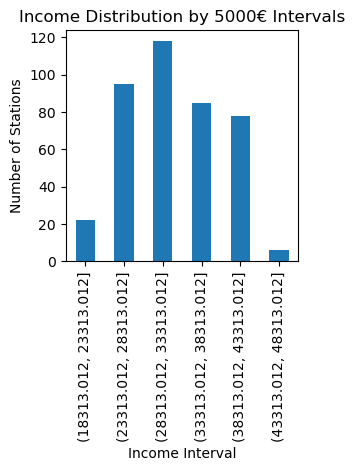

In [11]:
#4.1.2 Distribution in Intervals
df = station_buffers_income.dropna(subset=["income_mean"]).copy()
min_income = df["income_mean"].min()
max_income = df["income_mean"].max()

interval_width = 5000

n_intervals = int((max_income - min_income) / interval_width) + 1

bins = [min_income + i * interval_width for i in range(n_intervals + 1)]

df["income_interval"] = pd.cut(df["income_mean"], bins=bins)

interval_distribution = df["income_interval"].value_counts().sort_index()

interval_distribution.plot(kind="bar", figsize=(3,3))

plt.title("Income Distribution by 5000€ Intervals")
plt.xlabel("Income Interval")
plt.ylabel("Number of Stations")

plt.xticks(rotation=90)
plt.show()

INTERPRETATION: The distribution is approximately bell-shaped and right skewed

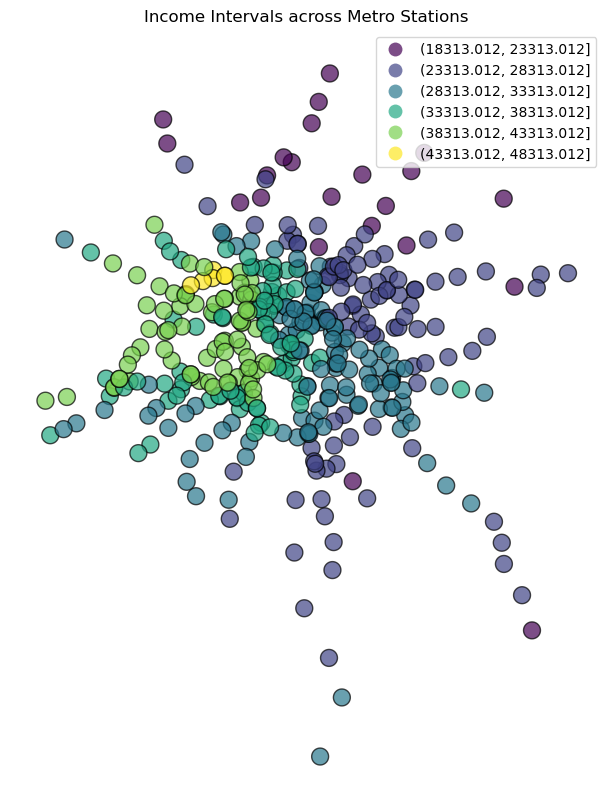

In [12]:
#4.1.3 Heatmap showing Intervals of the Station

#Static Map in the Notebook
fig, ax = plt.subplots(figsize=(10,10))

df.plot(
    column="income_interval",
    cmap="viridis",
    legend=True,
    ax=ax,
    edgecolor="black",
    alpha=0.7
)

ax.set_title("Income Intervals across Metro Stations")
ax.set_axis_off()

plt.show()

In [13]:
#Interactive Map in the 
df["income_interval"] = df["income_interval"].astype(str)

m = df.explore(
    column="income_interval",
    cmap="viridis"
)

m.save("../outputs/4_1_3_income_intervals_map.html")

INTERPRETATION: The heatmap confirms the intuition, that the stations in the inner west have on average a higher disposable income, while the rest of Paris is in the middle region, with the north-eastern edges and the banlieu beeing the lowest group.

Funfact, the map looks very similar to the latest 2026 election map which can be seen here: https://cdn.paris.fr/paris/2026/03/23/original-d3c6ce5863b0e898d4d156ece7ea7d23.png

## 4.2 Grouping Stations by Line
Now the stations are grouped by lines

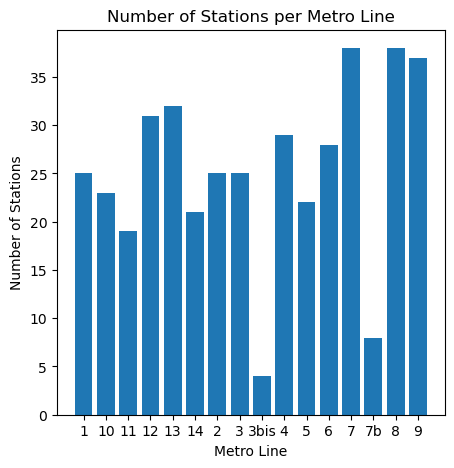

In [14]:
#Sorting the Lines
stations_per_line = df.groupby("indice_lig").size().reset_index(name="n_stations")
stations_per_line = stations_per_line.sort_values(by="indice_lig")

#Histogram 
plt.figure(figsize=(5,5))

plt.bar(
    stations_per_line["indice_lig"],
    stations_per_line["n_stations"]
)

plt.title("Number of Stations per Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Number of Stations")

plt.show()

In [15]:
#The filter is set for line with 10 or more stations
filtered = stations_per_line[
    stations_per_line["n_stations"] >= 10
].copy()

min_stations = filtered["n_stations"].min()
max_stations = filtered["n_stations"].max()
mean_stations = filtered["n_stations"].mean()

print(f"Line with the least stations: {min_stations}")
print(f"Line with the most stations: {max_stations}")
print(f"Average stations per line: {mean_stations:.2f}")

Line with the least stations: 19
Line with the most stations: 38
Average stations per line: 28.07


INTERPRETATION: Besides the 2 branch lines 3bis and 7b, most all of the stations are in a range of 19-38, with an average of 28 Stations

## 4.3 Income per Line
Now we sort the grouped lines by their average income

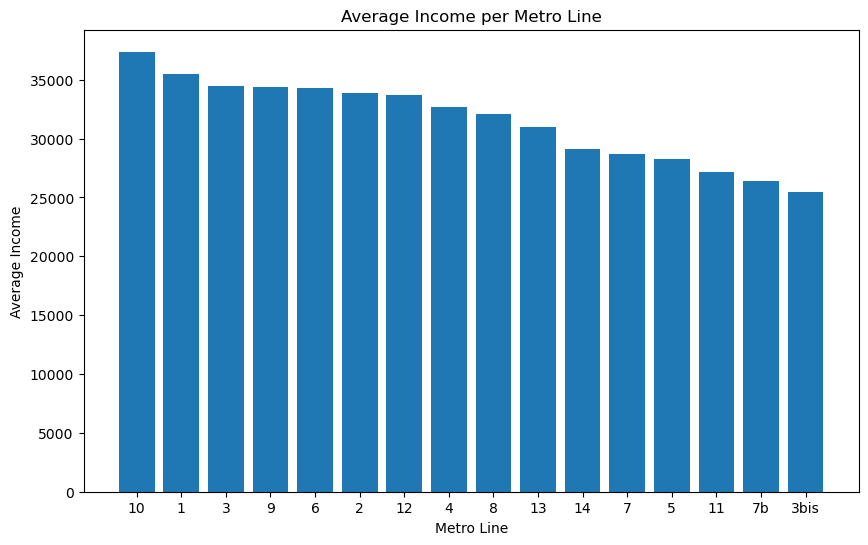


Average income per metro line :
Line 10: 37386.29
Line 1: 35456.14
Line 3: 34436.97
Line 9: 34378.12
Line 6: 34310.02
Line 2: 33854.09
Line 12: 33721.94
Line 4: 32683.56
Line 8: 32136.03
Line 13: 30956.58
Line 14: 29113.74
Line 7: 28692.55
Line 5: 28290.66
Line 11: 27208.51
Line 7b: 26366.00
Line 3bis: 25461.62


In [16]:
#Average Income
line_income = df.groupby("indice_lig")["income_mean"].mean().reset_index()
line_income = line_income.rename(columns={"income_mean": "mean_income"})

#Sort by value
line_income["line_num"] = line_income["indice_lig"].str.extract(r"(\d+)").astype(int)
line_income = line_income.sort_values(by=["mean_income"], ascending=False)

#Barchart
plt.figure(figsize=(10,6))

plt.bar(
    line_income["indice_lig"],
    line_income["mean_income"]
)

plt.title("Average Income per Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Average Income")

plt.xticks(rotation=0)

plt.show()

print("\nAverage income per metro line :")

for _, row in line_income.iterrows():
    print(f"Line {row['indice_lig']}: {row['mean_income']:.2f}")

INTERPRETATION: One can observes, that the two branch lines do have the lowest income. 
To get a better overview, the stations and lines will be combined in the following maps.

In [17]:
#Metrolines with average income = colorgrading and thickness

## 4.4 Inequality per Line
#Inequality per Line
#Interpretation

# 5. Regression

The goal of this exerceise is to investigate one choosen line and investigate wheather one can observe a regression for the income and the distance from the center. 
Since there was no open-source dataset that included the exact kilometer point at which each station is in the alignment, one has to work its way around it. From the given information in the station dataset, the most useful will therefore probably be the coordinates, together with some assumptions. 

On therefore needs to choose lines, in which the x or the y axis dictates the distance from the center, as the alignment functions as a north-south or east-west axis. Because of their characteristics, two lines are choosen:

- Metro Line 4 : North South Axis, as shown below, the income characeteristics of this line is, that the north and south are in the lower quantiles while the center is in the upper and middle quantiles. The first instinct would therefore be, that the income would look parabolic

- Meto Line 1: East West Axis, as shown below, one would assume a similar but less central distirbution, where beginning from the east the metro connects lower/middle income station with westward increasing income groups untill it reaches it peak near Etoile and declines untill Defense

Both lines pass through the station "Chatelet" , which is taken as a center due to its geographic location and importance as central node in the parisian transit system